In [ ]:
import zipfile
import os

for z in ["/content/set_a.zip", "/content/set_b.zip"]:
    if os.path.exists(z):
        print("Extracting", z)
        with zipfile.ZipFile(z, 'r') as zip_ref:
            zip_ref.extractall("/content")

Extracting /content/set_a.zip
Extracting /content/set_b.zip


In [ ]:
# =========================
# INSTALL + IMPORTS
# =========================
!pip install librosa soundfile scikit-learn matplotlib pandas

import pandas as pd
import glob
import os
import numpy as np

# ==============================
# LOAD LABELS
# ==============================

def load_labels(csv_path, base_folder):
    # read CSV
    df = pd.read_csv(csv_path)

    print(f"\nCSV preview ({base_folder}):")
    print(df.head())

    print("\nLabel distribution:")
    print(df["label"].value_counts())

    # get wav files
    wav_paths = glob.glob(f"/content/{base_folder}/**/*.wav", recursive=True)
    print(f"Found {len(wav_paths)} wav files in {base_folder}")

    label_map = {}
    matched = 0


    for _, row in df.iterrows():
        filename = str(row["fname"]).strip()
        label = str(row["label"]).strip().lower()

        file_only = os.path.basename(filename)

        #  extract unique ID
        parts = file_only.split("_")
        key_part = "_".join(parts[-2:]).replace(".wav", "")

        for p in wav_paths:
            if key_part in p:

                y = 0 if label == "normal" else 1
                label_map[p] = y
                matched += 1
                break

    print(f"✅ Matched {matched} files in {base_folder}")
    return label_map


# ==============================
# RUN LOADING
# ==============================

label_map_a = load_labels("/content/set_a.csv", "set_a")
label_map_b = load_labels("/content/set_b.csv", "set_b")

# merge datasets
label_map = {**label_map_a, **label_map_b}

print("\n🔥 TOTAL LABEL MAP:", len(label_map))


# =========================
# PREVIEW
# =========================
print("\nSample entries:")
for i, (k, v) in enumerate(label_map.items()):
    print(k, v)
    if i == 5:
        break


# =========================
# CLASS DISTRIBUTION
# =========================
y_vals = list(label_map.values())
print("\nClass distribution:", np.bincount(y_vals))


CSV preview (set_a):
  dataset                             fname     label  sublabel
0       a  set_a/artifact__201012172012.wav  artifact       NaN
1       a  set_a/artifact__201105040918.wav  artifact       NaN
2       a  set_a/artifact__201105041959.wav  artifact       NaN
3       a  set_a/artifact__201105051017.wav  artifact       NaN
4       a  set_a/artifact__201105060108.wav  artifact       NaN

Label distribution:
label
artifact    40
murmur      34
normal      31
extrahls    19
Name: count, dtype: int64
Found 176 wav files in set_a
✅ Matched 176 files in set_a

CSV preview (set_b):
  dataset                                              fname       label  \
0       b  set_b/Btraining_extrastole_127_1306764300147_C...  extrastole   
1       b  set_b/Btraining_extrastole_128_1306344005749_A...  extrastole   
2       b  set_b/Btraining_extrastole_130_1306347376079_D...  extrastole   
3       b  set_b/Btraining_extrastole_134_1306428161797_C...  extrastole   
4       b  set_b/Btra

In [ ]:
print("TOTAL LABEL MAP:", len(label_map))

for i, (k, v) in enumerate(label_map.items()):
    print(k, v)
    if i == 5:
        break

TOTAL LABEL MAP: 761
/content/set_a/artifact__201012172012.wav 1
/content/set_a/artifact__201105040918.wav 1
/content/set_a/artifact__201105041959.wav 1
/content/set_a/artifact__201105051017.wav 1
/content/set_a/artifact__201105060108.wav 1
/content/set_a/artifact__201105061143.wav 1


In [ ]:
# =========================
#  AUDIO PREPROCESSING
# =========================
import librosa
import numpy as np

TARGET_SR = 2000
DURATION = 3
SAMPLES = TARGET_SR * DURATION

def preprocess_audio(path):
    y, sr = librosa.load(path, sr=TARGET_SR)

    # pad / trim
    if len(y) < SAMPLES:
        y = np.pad(y, (0, SAMPLES - len(y)))
    else:
        y = y[:SAMPLES]

    # 🔹 MEL SPECTROGRAM
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
    mel = librosa.power_to_db(mel)

    # 🔹 MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)

    # 🔹 resize to same time dimension
    min_time = min(mel.shape[1], mfcc.shape[1])
    mel = mel[:, :min_time]
    mfcc = mfcc[:, :min_time]

    # 🔹 stack features
    combined = np.vstack([mel, mfcc])   # shape: (84, time)

    # normalize
    combined = (combined - np.mean(combined)) / (np.std(combined) + 1e-9)

    return combined

In [ ]:
# =========================
#  BUILD DATASET
# =========================
X = []
y = []
failures = []

for path, label in label_map.items():
    try:
        spec = preprocess_audio(path)
        X.append(spec)
        y.append(label)
    except Exception as e:
        failures.append(path)

print("Loaded:", len(X), "Failed:", len(failures))

X = np.array(X)[..., np.newaxis]
y = np.array(y).astype(int)

print("X shape:", X.shape)
print("Label distribution:", np.bincount(y))

print(X.shape)

Loaded: 761 Failed: 0
X shape: (761, 84, 12, 1)
Label distribution: [307 454]
(761, 84, 12, 1)


In [ ]:
# =========================
# TRAIN TEST SPLIT (FINAL)
# =========================

from sklearn.model_selection import train_test_split
import numpy as np

#  DO NOT redefine X, y — use existing ones from dataset

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))

print("Train class distribution:", np.bincount(y_train))
print("Validation class distribution:", np.bincount(y_val))

Train size: 608
Validation size: 153
Train class distribution: [245 363]
Validation class distribution: [62 91]


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

auto_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

auto_weights = dict(zip(classes, auto_weights))
print("Auto weights:", auto_weights)

#  OVERRIDE WITH MANUAL WEIGHTS
class_weights = {
    0: 2.0,   # boost normal class
    1: 1.0
}

print("Using manual weights:", class_weights)

Auto weights: {np.int64(0): np.float64(1.2408163265306122), np.int64(1): np.float64(0.837465564738292)}
Using manual weights: {0: 2.0, 1: 1.0}


In [ ]:
# =========================
#  MODEL
# =========================
import tensorflow as tf
from tensorflow.keras import layers, models

def build_model(input_shape):
    inp = layers.Input(shape=input_shape)

    # CNN feature extractor
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inp)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2,2))(x)

    # reshape for LSTM
    x = layers.Reshape((x.shape[1], -1))(x)

    # LSTM
    x = layers.LSTM(64, return_sequences=False)(x)

    # dense
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inp, out)

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

    return model

In [ ]:
# =========================
# TRAIN MODEL (ADD THIS)
# =========================

model = build_model(X_train.shape[1:])
model.summary()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=16,
    class_weight=class_weights
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 84, 12, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 84, 12, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 42, 6, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 42, 6, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 21, 3, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 21, 192)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,721 (338.75 KB)

 Trainable params: 86,721 (338.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 13s 163ms/step - accuracy: 0.4112 - auc: 0.5224 - loss: 0.9556 - val_accuracy: 0.4052 - val_auc: 0.5586 - val_loss: 0.7437
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.4523 - auc: 0.5724 - loss: 0.9448 - val_accuracy: 0.5948 - val_auc: 0.5680 - val_loss: 0.6791
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.5362 - auc: 0.6087 - loss: 0.9343 - val_accuracy: 0.4575 - val_auc: 0.5752 - val_loss: 0.8103
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.5247 - auc: 0.6409 - loss: 0.9163 - val_accuracy: 0.4771 - val_auc: 0.5751 - val_loss: 0.7051
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.5543 - auc: 0.6283 - loss: 0.9152 - val_accuracy: 0.4641 - val_auc: 0.5819 - val_loss: 0.7740
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.5214 - auc: 0.6344 - loss: 0.8991 - val_accuracy: 0.5163 - val_auc: 0.6172 - val_loss: 0.7010
Epoch 7/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 40

In [ ]:
# =========================
# FIND BEST THRESHOLD (ROC)
# =========================

from sklearn.metrics import roc_curve
import numpy as np

# Get probabilities
y_pred_prob = model.predict(X_val).ravel()

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_pred_prob)

# Youden’s J statistic
J = tpr - fpr

# Best threshold index
ix = np.argmax(J)
best_threshold = thresholds[ix]

print("Best Threshold:", best_threshold)
print("TPR (Recall):", tpr[ix])
print("FPR:", fpr[ix])

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Best Threshold: 0.25961637
TPR (Recall): 0.6263736263736264
FPR: 0.3387096774193548


In [ ]:
# =========================
# EVALUATION (FIXED)
# =========================

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred_prob = model.predict(X_val).ravel()
print("Sample predictions:", y_pred_prob[:10])

y_pred = (y_pred_prob >= best_threshold).astype(int)

print("Predicted class counts:", np.bincount(y_pred))
print("True class counts:", np.bincount(y_val))

print(classification_report(y_val, y_pred))
print(confusion_matrix(y_val, y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Sample predictions: [0.22935109 0.4057475  0.6896424  0.99933726 0.23106498 0.9829512
 0.25835213 0.25961637 0.24742693 0.26348513]
Predicted class counts: [75 78]
True class counts: [62 91]
              precision    recall  f1-score   support

           0       0.55      0.66      0.60        62
           1       0.73      0.63      0.67        91

    accuracy                           0.64       153
   macro avg       0.64      0.64      0.64       153
weighted avg       0.66      0.64      0.64       153

[[41 21]
 [34 57]]


In [ ]:
print("Sample predictions:", y_pred_prob[:10])
print("Predicted class counts:", np.bincount(y_pred))
print("True class counts:", np.bincount(y_val))

Sample predictions: [0.22935109 0.4057475  0.6896424  0.99933726 0.23106498 0.9829512
 0.25835213 0.25961637 0.24742693 0.26348513]
Predicted class counts: [75 78]
True class counts: [62 91]


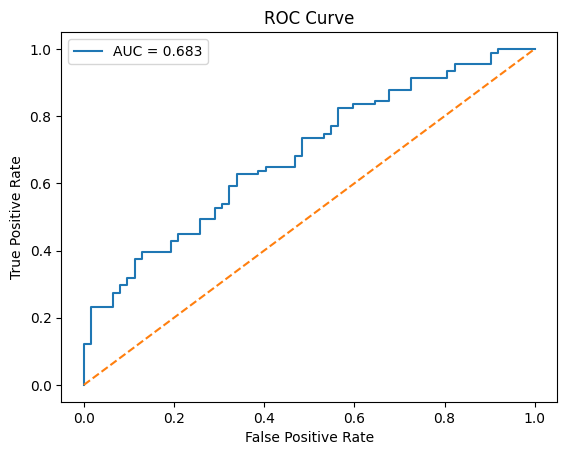

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_val, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()